# Association

**Association** measures the relationship between two categorical variables.

This is done in two steps:

1. To qualify the association as being **significant**, we'll be using ther Chi-square test
2. To quantify the **strength** of association, we'll be using Cramer's V

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Example 1: Titanic Survival and Class

People in higher `pclass` on the titanic may have had access to life boats or may have been simply treated better. Is there an association between that and whether they `survived` or not?

Let's find out..

In [ ]:
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


Create a contingency table to analyze the association between `survived` and `pclass`:

In [ ]:
contingency_table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
    normalize='index' # Percentage
)
contingency_table

survived,0,1
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In [ ]:
contingency_table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
    normalize='index' # Percentage
)
contingency_table

survived,0,1
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


Using a `heatmap` to add color and intensity makes it easier to read and compare:

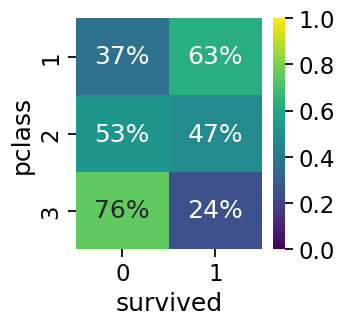

In [ ]:
plt.figure(figsize=(3, 3))
sns.heatmap(
    contingency_table,
    annot=True, cmap="viridis", fmt=".0%", vmin=0, vmax=1
);

### Step 1: Chi-square Test ($\chi^2$)

- The **Chi-squared test** is used to test for **association between two categorical variables**.
- However, it doesn't quantify how strong this association is.

Moreover, the test needs the **unnormalized** contingency table:

In [ ]:
contingency_table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
    # normalize='index'
)
contingency_table

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


Now let's apply the test: 

In [ ]:
from scipy.stats import chi2_contingency

# significance level
alpha = 0.05

# Run the Chi-Square Test
chi2_stat, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)

print("\n--- Chi-Square Test Results ---")
print(f"P-value: {p_value:.2e}")  # Scientific notation is useful here
print("significant!" if p_value <= alpha else "not enough evidence")


--- Chi-Square Test Results ---
P-value: 4.55e-23
significant!


Always check the p-value of your Chi-square test first. If the p-value is not significant (usually $p > 0.05$), the association is likely due to chance, and interpreting Cramér's V becomes moot. In our case, the $p < 0.05$ and hence we proceed..

We do not care about the `chi2_stat` and `expected_frequencies`, but, we will need the **Degrees of Freedom** (`dof = min(n_rows, n_cols)`) in interpreting Cramer's V test result. 

### Step 2: Calculate Cramer's V

In [ ]:
from scipy.stats.contingency import association

# Calculate Cramér's V
cramers_v = association(
    observed=contingency_table,
    method='cramer',
    correction=True
)

print(f"Cramér's V: {cramers_v:.2f}")

Cramér's V: 0.34


### Step 3: Interpreting the results

Cramér's V ranges from **0 to 1**. It does not indicate direction (since categorical data has no inherent order), only magnitude.

- **0**: No association between the variables.
- **1**: Perfect association (knowing the value of one variable allows you to perfectly predict the other).

Cohen (1988) provided general benchmarks for what constitutes a "small," "medium," or "large" effect, and can be generalized in the following snippet of code:

In [ ]:
def interpret_cramers_v(v: float, dof: int) -> str:
    benchmarks = {
        "Small": 0.1 / np.sqrt(dof),
        "Medium": 0.3 / np.sqrt(dof),
        "Large": 0.5 / np.sqrt(dof)
    }
    
    if v < benchmarks["Small"]:
        return "Negligible"
    elif v < benchmarks["Medium"]:
        return "Small"
    elif v < benchmarks["Large"]:
        return "Medium"
    else:
        return "Large"

In [ ]:
print(f"Degrees of Freedom: {dof}")
print("        Effect size:", interpret_cramers_v(cramers_v, dof))

Degrees of Freedom: 2
Effect size: Medium
